GradientBoosting: max acc = 0.9528 @ n_estimators = 98
AdaBoost        : max acc = 0.8472 @ n_estimators = 94


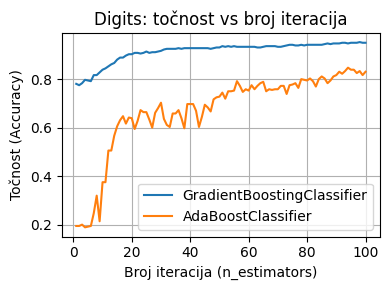

In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

X, y = load_digits(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 3) Definiraj modele s 100 estimatora
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=2,
                                random_state=42)
ada = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)

gb.fit(X_train, y_train)
ada.fit(X_train, y_train)

acc_gb = [accuracy_score(y_test, y_pred) for y_pred in gb.staged_predict(X_test)]
acc_ada = [accuracy_score(y_test, y_pred) for y_pred in ada.staged_predict(X_test)]
iters = np.arange(1, 101)

best_gb_idx = int(np.argmax(acc_gb))
best_ada_idx = int(np.argmax(acc_ada))
print(f"GradientBoosting: max acc = {acc_gb[best_gb_idx]:.4f} @ n_estimators = {best_gb_idx+1}")
print(f"AdaBoost        : max acc = {acc_ada[best_ada_idx]:.4f} @ n_estimators = {best_ada_idx+1}")

plt.figure(figsize=(4,3))
plt.plot(iters, acc_gb, label="GradientBoostingClassifier")
plt.plot(iters, acc_ada, label="AdaBoostClassifier")
plt.xlabel("Broj iteracija (n_estimators)")
plt.ylabel("Točnost (Accuracy)")
plt.title("Digits: točnost vs broj iteracija")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

